In [19]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

In [15]:
df_path = r"C:\Users\ivanf\Documents\Vortex\1.3 Vortex - Medical Cost\data\insurance.csv" ##Ubicar r antes de las comillas para evitar errroes de lectura con los backslashs
df_insurance = pd.read_csv(df_path)
df_insurance['smoker'] = (df_insurance['smoker'] == "yes").astype(int)
df_insurance['obese'] = (df_insurance['bmi'] >= 30).astype(int)
df_insurance_filter = df_insurance[['bmi','age','smoker']]
print(df_insurance_filter)

         bmi  age  smoker
0     27.900   19       1
1     33.770   18       0
2     33.000   28       0
3     22.705   33       0
4     28.880   32       0
...      ...  ...     ...
1333  30.970   50       0
1334  31.920   18       0
1335  36.850   18       0
1336  25.800   21       0
1337  29.070   61       1

[1338 rows x 3 columns]


In [22]:
## Creacion del objeto Scaler
scaler = StandardScaler()
## Estandarizacion del df, fit obtiene la media y la desviacion (distancia entre puntos) y transformo los estandariza
df_scaled = scaler.fit_transform(df_insurance_filter)
print(df_scaled[:5])

[[-0.45332    -1.43876426  1.97058663]
 [ 0.5096211  -1.50996545 -0.5074631 ]
 [ 0.38330685 -0.79795355 -0.5074631 ]
 [-1.30553108 -0.4419476  -0.5074631 ]
 [-0.29255641 -0.51314879 -0.5074631 ]]


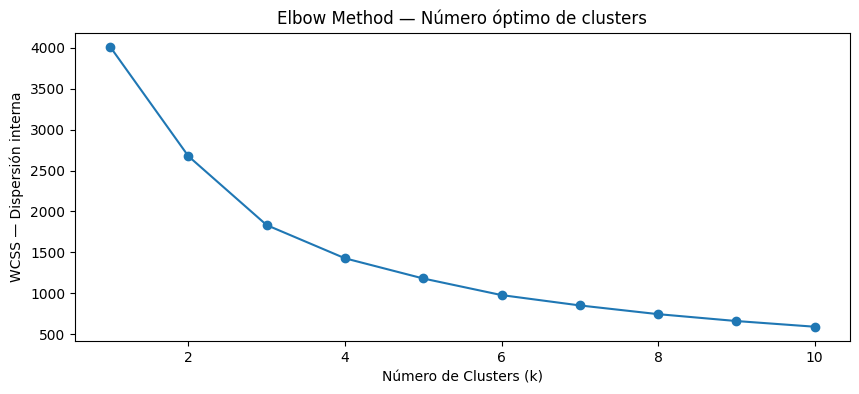

In [23]:
# Lista vacía donde guardaremos el WCSS de cada k
wcss = []

# Probamos K-Means con k=1 hasta k=10
for k in range(1, 11):
    
    # Creamos el modelo con k clusters
    # random_state=42 → resultados reproducibles
    # n_init=10 → corre 10 veces y se queda con el mejor
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    
    # Entrenamos el modelo con los datos escalados
    kmeans.fit(df_scaled)
    
    # inertia_ es el WCSS calculado automáticamente
    # Mide qué tan dispersos están los puntos dentro de cada cluster
    wcss.append(kmeans.inertia_)

# Graficamos k vs WCSS para encontrar el codo
plt.figure(figsize=(10, 4))
plt.plot(range(1, 11), wcss, marker='o')
plt.title('Elbow Method — Número óptimo de clusters')
plt.xlabel('Número de Clusters (k)')
plt.ylabel('WCSS — Dispersión interna')
plt.show()

In [28]:
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
kmeans.fit(df_scaled)
df_insurance['segmento_riesgo'] = kmeans.labels_
print(df_insurance['segmento_riesgo'].value_counts().sort_index())

segmento_riesgo
0    516
1    548
2    274
Name: count, dtype: int64


In [29]:
df_insurance.groupby('segmento_riesgo')[['age', 'bmi', 'smoker', 'charges']].mean().round(2)

,age,bmi,smoker,charges
segmento_riesgo,,,,
0,26.81,29.43,0.0,5059.76
1,51.22,31.80,0.0,11611.73
2,38.51,30.71,1.0,32050.23


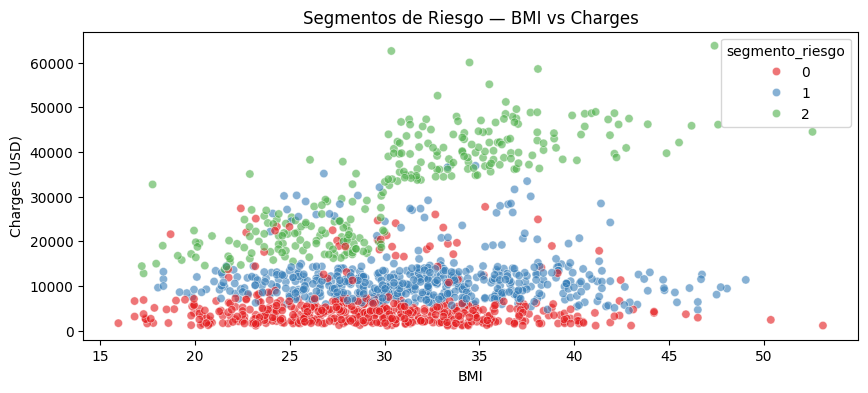

In [30]:
plt.figure(figsize=(10, 4))

sns.scatterplot(data=df_insurance, x='bmi', y='charges', 
                hue='segmento_riesgo', palette='Set1', alpha=0.6)

plt.title('Segmentos de Riesgo — BMI vs Charges')
plt.xlabel('BMI')
plt.ylabel('Charges (USD)')
plt.show()